# RQ4 — Post-hoc Perturbation Attribution

In [1]:
import sys

sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiments._loader import load_all_results, success_only
from experiments._analysis import setup_matplotlib, tex

setup_matplotlib()

df_all = load_all_results(include_baseline_fail=True)
# A saved final genome exists only for completed optimizer runs; baseline failures
# are therefore intentionally excluded from genome attribution.
df = success_only(df_all)

MODELS = [m for m in sorted(df.model.unique()) if (df.model == m).sum() >= 30]
MODEL_LABEL = {
    "qwen": "Qwen3-VL", "kimi": "Kimi-VL", "intern": "InternVL-3.5",
    "gemma": "Gemma3-4B", "deepseek": "Deepseek-VL2", "nemotron": "Nemotron3-ON",
}
SCENE_LABEL = {"single/solo": "SC-SI", "single/multi": "SC-MI", "multi": "MC", "udacity": "Driving"}
SCENES = ["single/solo", "single/multi", "multi", "udacity"]
SUCCESS_IOU = 0.25
ACTIVATION_EPSILON = 0.01

# Descriptive taxonomy for the existing perturbation operators.
FAMILY_COLUMNS = {
    "Digital": ["img_jpeg_filter", "img_pixelate", "img_cutout"],
    "Blur": ["img_defocus_blur", "img_motion_blur"],
    "Noise": ["img_gaussian_noise"],
    "Color": ["img_contrast", "img_false_color", "img_grayscale"],
    "Geometric": ["img_elastic"],
    "Weather/env.": ["img_fog_filter", "img_snow_filter"],
    "Orthographic": ["txt_fragmentation", "txt_character_noise"],
    "Semantic": ["txt_homophone", "txt_synonym", "txt_ata_saliency"],
    "Instruction": ["txt_universal_suffix_injection", "txt_context_rot_injection", "txt_task_reinforcement"],
}
FAMILY_MODALITY = {family: ("image" if columns[0].startswith("img_") else "text") for family, columns in FAMILY_COLUMNS.items()}
FAMILIES = list(FAMILY_COLUMNS)


def mlabel(model):
    return MODEL_LABEL.get(model, tex(model))


def add_family_attribution(frame):
    """Add modality-normalised family shares and dominant-family labels."""
    out = frame.copy()
    for family, columns in FAMILY_COLUMNS.items():
        out[f"family_{family}"] = out[columns].sum(axis=1)
    for family in FAMILIES:
        modality = FAMILY_MODALITY[family]
        denominator = out["img_budget_used"] if modality == "image" else out["txt_budget_used"]
        supported = out["genome_mode"].isin(["multi", modality])
        out[f"share_{family}"] = np.where(supported & denominator.gt(0), out[f"family_{family}"] / denominator, np.nan)
    family_values = out[[f"family_{family}" for family in FAMILIES]].copy()
    for family in FAMILIES:
        modality = FAMILY_MODALITY[family]
        family_values.loc[~out["genome_mode"].isin(["multi", modality]), f"family_{family}"] = np.nan
    out["dominant_family"] = family_values.idxmax(axis=1).str.removeprefix("family_")
    out["attack_success"] = out["final_iou"].le(SUCCESS_IOU)
    return out


attrib = add_family_attribution(df)
print("Models:", [mlabel(model) for model in MODELS])
print(f"Completed optimizer runs with genomes: {len(attrib)}")
print(f"IoU-degraded runs (final IoU <= {SUCCESS_IOU:g}): {attrib['attack_success'].sum()}")

Models: ['InternVL-3.5', 'Kimi-VL', 'Nemotron3-ON', 'Qwen3-VL']
Completed optimizer runs with genomes: 2091
IoU-degraded runs (final IoU <= 0.25): 1480


In [2]:
[f"{m} {(df.model == m).sum()}" for m in df.model.unique()]

['deepseek 24',
 'gemma 12',
 'intern 396',
 'kimi 330',
 'nemotron 492',
 'qwen 837']

## Post-hoc perturbation attribution

The final genome is treated as an allocation profile: each severity is grouped into a perturbation family and normalised by the corresponding image or text budget. This is a descriptive usage analysis, not a leave-one-family-out ablation: a near-zero allocation can also indicate redundancy with another operator.

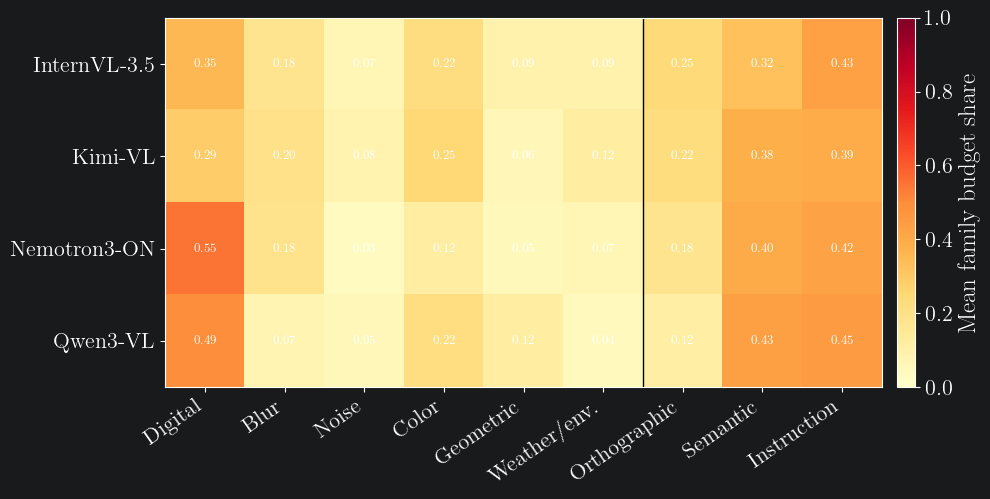

In [8]:
# Mean final-genome allocation, conditioned on an operator family being available.
rows = []
for model in MODELS:
    for family in FAMILIES:
        subset = attrib[(attrib["model"] == model) & attrib[f"share_{family}"].notna()]
        rows.append({"model": model, "family": family, "mean_share": subset[f"share_{family}"].mean(), "n": len(subset)})
share_summary = pd.DataFrame(rows)
share_table = share_summary.pivot(index="model", columns="family", values="mean_share").reindex(MODELS)

fig, ax = plt.subplots(figsize=(0.82 * len(FAMILIES) + 2.4, 0.7 * len(MODELS) + 2.0))
im = ax.imshow(share_table[FAMILIES], cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(FAMILIES)))
ax.set_xticklabels(FAMILIES, rotation=35, ha="right")
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels([mlabel(model) for model in MODELS])
for i, model in enumerate(MODELS):
    for j, family in enumerate(FAMILIES):
        value = share_table.loc[model, family]
        if pd.notna(value): ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9)
ax.axvline(5.5, color="black", lw=1)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Mean family budget share")
fig.savefig("figures/rq4_family_budget_share.pdf", dpi=200, bbox_inches="tight")
plt.show()

## Operator activation frequency

An operator is active when its final severity exceeds $epsilon=0.01$. Frequencies are calculated among IoU-degraded runs only, so they describe mechanisms used in discovered failures rather than allocation in weaker outcomes.

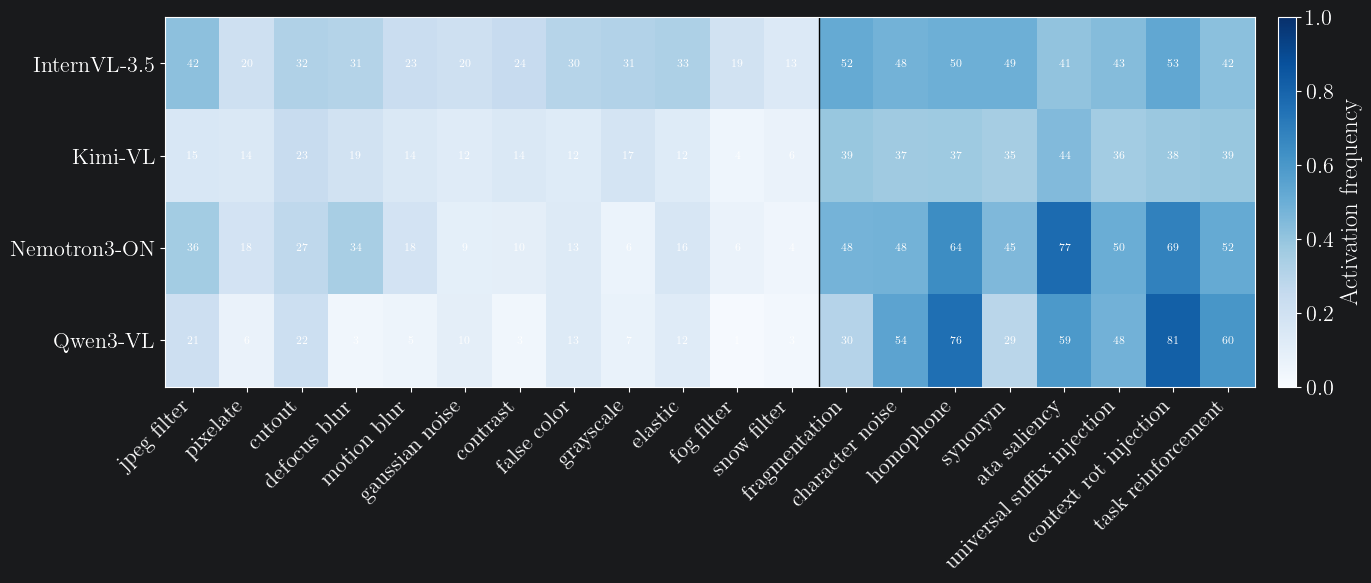

In [9]:
OPERATOR_COLUMNS = [column for columns in FAMILY_COLUMNS.values() for column in columns]
OPERATOR_LABELS = [tex(column.removeprefix("img_").removeprefix("txt_")) for column in OPERATOR_COLUMNS]
successes = attrib[attrib["attack_success"]].copy()
activation = (
    successes[successes["model"].isin(MODELS)].groupby("model")[OPERATOR_COLUMNS]
    .agg(lambda values: values.gt(ACTIVATION_EPSILON).mean()).reindex(MODELS)
)

fig, ax = plt.subplots(figsize=(0.62 * len(OPERATOR_COLUMNS) + 2.4, 0.7 * len(MODELS) + 2.0))
im = ax.imshow(activation, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(OPERATOR_COLUMNS)))
ax.set_xticklabels(OPERATOR_LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels([mlabel(model) for model in MODELS])
for i in range(len(MODELS)):
    for j in range(len(OPERATOR_COLUMNS)):
        value = activation.iloc[i, j]
        if pd.notna(value): ax.text(j, i, f"{value:.0%}", ha="center", va="center", fontsize=8)
ax.axvline(11.5, color="black", lw=1)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label(f"Activation frequency")
fig.savefig("figures/rq4_operator_activation.pdf", dpi=200, bbox_inches="tight")
plt.show()

## Dominant-family frequency

For each final genome, the dominant family is the available family with the largest unnormalised severity sum. The table retains the scene dimension so concentration in one scene type is visible rather than hidden by model-level averages.

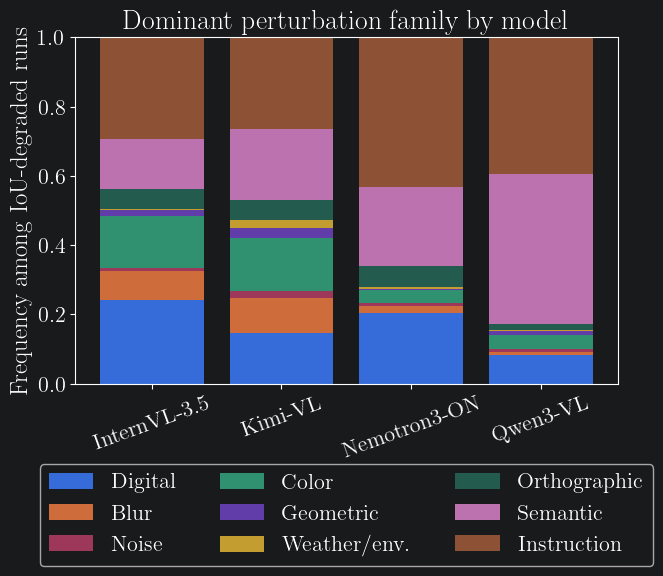

In [10]:
dominant = (successes[successes["model"].isin(MODELS)].groupby(["model", "obj_category", "dominant_family"]).size().rename("runs").reset_index())
dominant["frequency"] = dominant["runs"] / dominant.groupby(["model", "obj_category"])["runs"].transform("sum")
dominant_table = dominant.pivot_table(index=["model", "obj_category"], columns="dominant_family", values="frequency", fill_value=0).reindex(columns=FAMILIES, fill_value=0)

model_dominant = (successes[successes["model"].isin(MODELS)].groupby(["model", "dominant_family"]).size().unstack(fill_value=0).reindex(index=MODELS, columns=FAMILIES, fill_value=0))
model_dominant = model_dominant.div(model_dominant.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(max(7, 1.5 * len(MODELS)), 4.5))
bottom = np.zeros(len(MODELS))
for family in FAMILIES:
    values = model_dominant[family].to_numpy()
    ax.bar([mlabel(model) for model in MODELS], values, bottom=bottom, label=family)
    bottom += values
ax.set_ylabel("Frequency among IoU-degraded runs")
ax.set_ylim(0, 1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)
ax.tick_params(axis="x", rotation=20)
ax.set_title("Dominant perturbation family by model")
fig.savefig("figures/rq4_dominant_family_frequency.pdf", dpi=200, bbox_inches="tight")
plt.show()

### Recoverability

In [7]:
import json
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image

from experiments._analysis import (
    RECOVERY_COLORS,
    RECOVERY_ORDER,
    classify_termination_series,
    evaluate_recovered_predictions,
    recover_json_bboxes_with_ollama,
    resolve_original_image_path,
)
from experiments.config.experiment import BASELINE_IOU_MIN
from experiments.config.paths import OLLAMA_HOST

df_term = classify_termination_series(df_all)
malformed = df_term[df_term["termination_type"] == "JSON malformed"].copy()
print(f"Malformed JSON rows: {len(malformed)}")

records = []
for i, (_, row) in tqdm(enumerate(malformed.iterrows(), start=1)):
    artifact = json.loads(Path(row["_result_json_path"]).read_text())
    vlm_output = artifact.get("vlm_output", {})
    raw_response = str(vlm_output.get("raw_response", "") or "")
    prompt_objects = vlm_output.get("prompt_objects", [])
    gt_boxes = artifact.get("ground_truth_bboxes", [])

    recovered_iou = np.nan
    recovered_count = 0
    recoverability = "Unrecoverable"

    if raw_response and gt_boxes:
        recovered = recover_json_bboxes_with_ollama(
            raw_response,
            prompt_objects,
            model="granite4.1:8b",
            host=OLLAMA_HOST,
            timeout=180,
        )
        if recovered:
            with Image.open(resolve_original_image_path(str(row["_orig_img_folder"]))) as image:
                original_size = image.size
            recovered_iou = evaluate_recovered_predictions(
                recovered,
                gt_boxes,
                original_size,
                model_name=str(row["model"]),
            )
            recovered_count = len(recovered)
            recoverability = (
                "Recovered and would pass"
                if recovered_iou >= BASELINE_IOU_MIN
                else "Recovered but still fail"
            )

    records.append(
        {
            "model": row["model"],
            "folder_id": row["folder_id"],
            "recoverability": recoverability,
            "recovered_iou": recovered_iou,
            "recovered_count": recovered_count,
        }
    )

recovery_df = pd.DataFrame(records)

Malformed JSON rows: 906


0it [00:00, ?it/s]

<>:21: SyntaxWarning: invalid escape sequence '\#'
<>:21: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_3590042/668836819.py:21: SyntaxWarning: invalid escape sequence '\#'
  ax.set_ylabel("\# Malformed JSON")


recoverability,Unrecoverable,Recovered but still fail,Recovered and would pass
Deepseek-VL2,99,1,0
Gemma3-4B,12,0,0
InternVL-3.5,38,3,9
Kimi-VL,341,59,177
Nemotron3-ON,21,2,4
Qwen3-VL,100,30,10


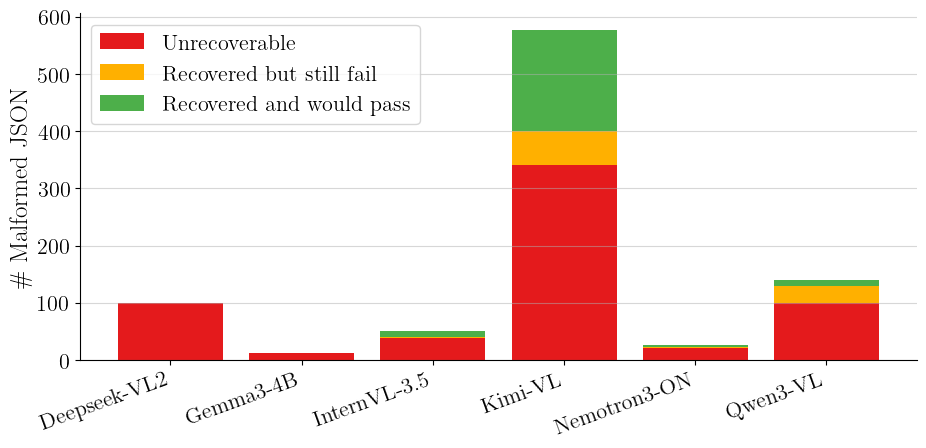

In [8]:
summary = recovery_df.groupby(["model", "recoverability"]).size().unstack(fill_value=0)
for label in RECOVERY_ORDER:
    if label not in summary.columns:
        summary[label] = 0
summary = summary[RECOVERY_ORDER].sort_index()

summary_named = summary.copy()
summary_named.index = [mlabel(model) for model in summary_named.index]
display(summary_named)

fig, ax = plt.subplots(figsize=(max(6, 1.8 * len(summary_named)), 4.5))
bottom = np.zeros(len(summary_named), dtype=float)
x = np.arange(len(summary_named))
ax.grid(axis="y", alpha=0.5)
for label in RECOVERY_ORDER:
    values = summary_named[label].to_numpy(dtype=float)
    ax.bar(x, values, bottom=bottom, color=RECOVERY_COLORS[label], label=label)
    bottom += values
ax.set_xticks(x)
ax.set_xticklabels(summary_named.index, rotation=20, ha="right")
ax.set_ylabel("\# Malformed JSON")
ax.legend(loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.savefig("figures/recovery.pdf", dpi=200, bbox_inches="tight")

### BBox Size Correlation

In [ ]:
import json
from pathlib import Path

from experiments._analysis import TERMINATION_COLORS, TERMINATION_ORDER, classify_termination_series
from experiments._loader import RESULTS_ROOT

BBOX_FEATURES = [
    "bbox_count",
    "bbox_area_pct_mean",
    "bbox_area_pct_median",
    "bbox_area_pct_max",
    "bbox_area_pct_min",
    "small_bbox_frac_side05",
]
BBOX_PRIMARY = "bbox_area_pct_median"
BBOX_SECONDARY = "small_bbox_frac_side05"
BBOX_MODELS = sorted(df_all["model"].unique())


def _original_json_path(folder_value):
    folder = Path(str(folder_value))
    if not folder.is_absolute():
        folder = RESULTS_ROOT / folder
    return folder / "original.json"


def _bbox_feature_row(folder_value):
    path = _original_json_path(folder_value)
    payload = json.loads(path.read_text())
    width, height = payload["original_dims"]
    boxes = list((payload.get("ground_truth") or {}).values())
    area_pcts = []
    small_flags = []
    for box in boxes:
        bw = max(0.0, float(box["xmax"]) - float(box["xmin"]))
        bh = max(0.0, float(box["ymax"]) - float(box["ymin"]))
        wf = bw / float(width)
        hf = bh / float(height)
        area_pcts.append((bw * bh) / float(width * height))
        small_flags.append(float((wf < 0.05) and (hf < 0.05)))
    return {
        "_orig_img_folder": str(folder_value),
        "bbox_count": int(len(area_pcts)),
        "bbox_area_pct_mean": float(np.mean(area_pcts)),
        "bbox_area_pct_median": float(np.median(area_pcts)),
        "bbox_area_pct_max": float(np.max(area_pcts)),
        "bbox_area_pct_min": float(np.min(area_pcts)),
        "small_bbox_frac_side05": float(np.mean(small_flags)),
    }


bbox_meta = pd.DataFrame(
    [_bbox_feature_row(folder) for folder in sorted(df_all["_orig_img_folder"].dropna().unique())]
)
df_bbox = classify_termination_series(df_all.merge(bbox_meta, on="_orig_img_folder", how="left"))
df_bbox["is_success"] = df_bbox["status"].eq("success").astype(int)

quartile_codes = pd.qcut(df_bbox[BBOX_PRIMARY], 4, labels=False, duplicates="drop")
quartile_count = int(quartile_codes.max() + 1)
quartile_labels = [f"Q{i + 1}" for i in range(quartile_count)]
df_bbox["bbox_area_pct_median_q"] = pd.Categorical(
    [quartile_labels[int(i)] if pd.notna(i) else np.nan for i in quartile_codes],
    categories=quartile_labels,
    ordered=True,
)

secondary_codes = pd.qcut(df_bbox[BBOX_SECONDARY].rank(method="first"), 4, labels=False, duplicates="drop")
secondary_count = int(secondary_codes.max() + 1)
secondary_labels = [f"Q{i + 1}" for i in range(secondary_count)]
df_bbox["small_bbox_frac_side05_q"] = pd.Categorical(
    [secondary_labels[int(i)] if pd.notna(i) else np.nan for i in secondary_codes],
    categories=secondary_labels,
    ordered=True,
)

missing_bbox = df_bbox[df_bbox[BBOX_FEATURES].isna().any(axis=1)][
    ["model", "folder_id", "filename", "_orig_img_folder"]
]
print(f"Rows with matched bbox metadata: {len(df_bbox) - len(missing_bbox)} / {len(df_bbox)}")
if len(missing_bbox):
    display(missing_bbox.drop_duplicates().head(20))

assert (df_bbox["bbox_count"] >= 1).all()
assert ((df_bbox["bbox_area_pct_min"] > 0) & (df_bbox["bbox_area_pct_max"] <= 1)).all()
assert ((df_bbox["small_bbox_frac_side05"] >= 0) & (df_bbox["small_bbox_frac_side05"] <= 1)).all()

term_counts = pd.crosstab(df_bbox["model"], df_bbox["termination_type"])
for label in TERMINATION_ORDER:
    if label not in term_counts.columns:
        term_counts[label] = 0
term_counts = term_counts[TERMINATION_ORDER].sort_index()
success_check = term_counts.sum(axis=1).rename("termination_total").to_frame()
success_check["row_total"] = df_bbox.groupby("model").size()
assert (success_check["termination_total"] == success_check["row_total"]).all()

model_summary = (
    df_bbox.groupby("model")
    .agg(
        testcase_count=("model", "size"),
        success_rate=("is_success", "mean"),
        mean_bbox_count=("bbox_count", "mean"),
        mean_bbox_area_pct_median=("bbox_area_pct_median", "mean"),
        mean_small_bbox_frac_side05=("small_bbox_frac_side05", "mean"),
        malformed_json_rate=("termination_type", lambda s: float((s == "JSON malformed").mean())),
    )
    .sort_index()
)
model_summary.index = [mlabel(model) for model in model_summary.index]

In [ ]:
success_by_q = (
    df_bbox.groupby(["bbox_area_pct_median_q", "model"])["is_success"]
    .mean()
    .unstack("model")
    .reindex(index=quartile_labels, columns=BBOX_MODELS)
)
n_models = len(BBOX_MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(max(10, 3.1 * n_models), 4.6), sharey=True)
if n_models == 1:
    axes = [axes]
for ax, model in zip(axes, BBOX_MODELS):
    sub = df_bbox[df_bbox["model"] == model]
    counts = pd.crosstab(sub["bbox_area_pct_median_q"], sub["termination_type"]).reindex(quartile_labels)
    for label in TERMINATION_ORDER:
        if label not in counts.columns:
            counts[label] = 0
    counts = counts[TERMINATION_ORDER]
    props = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    bottom = np.zeros(len(quartile_labels), dtype=float)
    for label in TERMINATION_ORDER:
        values = props[label].fillna(0).to_numpy(dtype=float)
        ax.bar(quartile_labels, values, bottom=bottom, color=TERMINATION_COLORS[label], label=label)
        bottom += values
    ax.set_title(mlabel(model))
    ax.set_xlabel(tex(BBOX_PRIMARY))
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
axes[0].set_ylabel("Termination share")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=3, bbox_to_anchor=(0.5, 1.14))
fig.tight_layout()
fig.savefig("figures/rq4_bbox_termination_mix.pdf", dpi=200, bbox_inches="tight")
plt.show()
